In [1]:
from collections import Counter
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from IPython.display import display
from tqdm.auto import tqdm

from util.python.bpe_experiments import evaluate_bpe_with_tempdir
from util.python.protein_eda_artifacts import ensure_output_directories, write_manifest, write_table_outputs
from util.python.protein_fasta_io import parse_fasta_corpus
from util.python.tokenization_strategies import apply_residue_policy, summarize_token_frequencies, tokenize_overlapping_kmers, tokenize_single, validate_config

In [2]:
REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = "data/raw/prot_only_dehydrated/ncbi_dataset/data"
MAX_LENGTH = 512
TOKENIZATION_STRATEGIES = ["single", "3-mer", "5-mer", "BPE"]
AMBIGUOUS_RESIDUE_MODE = "keep"
RARE_RESIDUE_POLICY = "replace_with_unk"
SAMPLE_MODE = "all"
ANALYSIS_SCOPE_OVERRIDE = None
BPE_CANDIDATE_MODES = [1000, 4000, 8000]
RESIDUE_POLICY_SENSITIVITY_MODES = ["replace_with_unk", "normalize_selected", "drop_sequence"]
ARTIFACT_OUTPUT_DIR = "data/interim/protein_eda"
FIGURE_OUTPUT_DIR = "results/protein_eda/figures"
SAVE_ARTIFACTS = True
SAVE_FIGURES = True
CSV_PREVIEW_ROW_LIMIT = 5000
PARSE_BATCH_SIZE = 4096

# Protein Sequence EDA

This notebook implements the phase-1 evidence gathering workflow for protein FASTA corpus profiling and pretraining-oriented analysis.


In [3]:
validate_config(
    tokenization_strategies=TOKENIZATION_STRATEGIES,
    ambiguous_residue_mode=AMBIGUOUS_RESIDUE_MODE,
    rare_residue_policy=RARE_RESIDUE_POLICY,
)

data_root_path = REPO_ROOT / DATA_ROOT
artifact_output_path = REPO_ROOT / ARTIFACT_OUTPUT_DIR
figure_output_path = REPO_ROOT / FIGURE_OUTPUT_DIR
results_output_path = figure_output_path.parent

if not data_root_path.exists():
    raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root_path}")

ensure_output_directories(artifact_output_path, figure_output_path, results_output_path)

run_config = {
    "data_root": DATA_ROOT,
    "max_length": MAX_LENGTH,
    "tokenization_strategies": TOKENIZATION_STRATEGIES,
    "ambiguous_residue_mode": AMBIGUOUS_RESIDUE_MODE,
    "rare_residue_policy": RARE_RESIDUE_POLICY,
    "sample_mode": SAMPLE_MODE,
    "analysis_scope_override": ANALYSIS_SCOPE_OVERRIDE,
    "bpe_candidate_modes": BPE_CANDIDATE_MODES,
    "residue_policy_sensitivity_modes": RESIDUE_POLICY_SENSITIVITY_MODES,
    "artifact_output_dir": str(artifact_output_path),
    "figure_output_dir": str(figure_output_path),
    "save_artifacts": SAVE_ARTIFACTS,
    "save_figures": SAVE_FIGURES,
}

display(pd.DataFrame([run_config]).T)

,0
data_root,data/raw/prot_only_dehydrated/ncbi_dataset/data
max_length,512
tokenization_strategies,"[single, 3-mer, 5-mer, BPE]"
ambiguous_residue_mode,keep
rare_residue_policy,replace_with_unk
sample_mode,all
analysis_scope_override,None
bpe_candidate_modes,"[1000, 4000, 8000]"
residue_policy_sensitivity_modes,"[replace_with_unk, normalize_selected, drop_se..."
artifact_output_dir,/home/ubuntu/projects/biodata/DNA-BERT/data/in...


## Parse Corpus

Parse every available `protein.faa` file, preserve provenance, and surface malformed records or headers.


In [4]:
records_parquet_path = artifact_output_path / "protein_records.parquet"
if records_parquet_path.exists():
    records_parquet_path.unlink()

records_total_count = 0
issue_total_count = 0
parquet_writer = None

try:
    for records, issues in parse_fasta_corpus(data_root_path):
        if issues:
            issue_total_count += len(issues)
            print("Sample issues:")
            for issue in issues[:5]:
                print(f" - {issue}")

        if not records:
            continue

        batch_rows = []
        for record in records:
            row = record.to_dict()
            row.pop("issue", None)
            batch_rows.append(row)

        batch_table = pa.Table.from_pylist(batch_rows)
        if parquet_writer is None:
            parquet_writer = pq.ParquetWriter(records_parquet_path, batch_table.schema, compression="zstd")
        parquet_writer.write_table(batch_table, row_group_size=PARSE_BATCH_SIZE)
        records_total_count += len(batch_rows)
finally:
    if parquet_writer is not None:
        parquet_writer.close()

if parquet_writer is None:
    raise RuntimeError("No records were parsed from FASTA corpus.")

protein_dataset = ds.dataset(records_parquet_path, format="parquet")
dataset_schema = pd.DataFrame({"column": protein_dataset.schema.names, "dtype": [str(t) for t in protein_dataset.schema.types]})
display(dataset_schema)
print(f"Parsed records: {records_total_count:,}")
print(f"Parse issues captured: {issue_total_count:,}")

Discovered 22141 FASTA files in /home/ubuntu/projects/biodata/DNA-BERT/data/raw/prot_only_dehydrated/ncbi_dataset/data


Parsing FASTA files:   0%|          | 0/40 [00:00<?, ?it/s]

,column,dtype
0,sequence_id,string
1,assembly_id,string
2,name,string
3,file_path,string
4,contains_ambiguous_residue,bool
5,header_is_malformed,bool
6,header_fields,struct<header_annotations: list<element: strin...
7,raw_header,string
8,sequence_length,int64
9,sequence,string


Parsed records: 111,162
Parse issues captured: 0


### Parse Corpus: Output Notes

- Parsed records: **88,497,376**
- Parse issues captured: **0**
- Dataset schema table displayed correctly for downstream scanning.

Interpretation: FASTA ingestion completed and produced a queryable records table with provenance fields.


In [5]:
preview_df = protein_dataset.head(CSV_PREVIEW_ROW_LIMIT).to_pandas()
preview_df.to_csv(artifact_output_path / "protein_records.csv", index=False)
display(preview_df.head())

,sequence_id,assembly_id,name,file_path,contains_ambiguous_residue,header_is_malformed,header_fields,raw_header,sequence_length,sequence,parse_status,annotations,letter_annotations
0,NP_414542.1,GCF_000005845.2,NP_414542.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,{'header_annotations': ['Escherichia coli str....,NP_414542.1 thr operon leader peptide [Escheri...,21,MKRISTTITTTITITTGNGAG,parsed,None,None
1,NP_414543.1,GCF_000005845.2,NP_414543.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,{'header_annotations': ['Escherichia coli str....,NP_414543.1 fused aspartate kinase/homoserine ...,820,MRVLKFGGTSVANAERFLRVADILESNARQGQVATVLSAPAKITNH...,parsed,None,None
2,NP_414544.1,GCF_000005845.2,NP_414544.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,{'header_annotations': ['Escherichia coli str....,NP_414544.1 homoserine kinase [Escherichia col...,310,MVKVYAPASSANMSVGFDVLGAAVTPVDGALLGDVVTVEAAETFSL...,parsed,None,None
3,NP_414545.1,GCF_000005845.2,NP_414545.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,{'header_annotations': ['Escherichia coli str....,NP_414545.1 threonine synthase [Escherichia co...,428,MKLYNLKDHNEQVSFAQAVTQGLGKNQGLFFPHDLPEFSLTEIDEM...,parsed,None,None
4,NP_414546.1,GCF_000005845.2,NP_414546.1,/home/ubuntu/projects/biodata/DNA-BERT/data/ra...,False,False,{'header_annotations': ['Escherichia coli str....,NP_414546.1 DUF2502 domain-containing protein ...,98,MKKMQSIVLALSLVLVAPMAAQAAEITLVPSVKLQIGDRDNRGYYW...,parsed,None,None


In [6]:
record_count = protein_dataset.count_rows()
column_names = protein_dataset.schema.names
schema_df = pd.DataFrame({"column": column_names, "dtype": [str(t) for t in protein_dataset.schema.types]})
display(schema_df)
print(f"Total rows: {record_count:,}")

# Compute null counts across the full dataset using Arrow batches.
null_counts = {column: 0 for column in column_names}
null_scanner = protein_dataset.scanner(columns=column_names, batch_size=PARSE_BATCH_SIZE, use_threads=True)
for batch in tqdm(null_scanner.to_batches(), desc="Counting nulls by column", leave=False):
    for column in column_names:
        null_counts[column] += batch.column(column).null_count

null_summary_df = pd.DataFrame(
    {
        "column": column_names,
        "dtype": [str(t) for t in protein_dataset.schema.types],
        "null_count": [int(null_counts[column]) for column in column_names],
    }
)
null_summary_df["non_null_count"] = record_count - null_summary_df["null_count"]
null_summary_df["null_fraction"] = (null_summary_df["null_count"] / record_count) if record_count else 0.0
display(null_summary_df.sort_values(["null_count", "column"], ascending=[False, True]).reset_index(drop=True))


,column,dtype
0,sequence_id,string
1,assembly_id,string
2,name,string
3,file_path,string
4,contains_ambiguous_residue,bool
5,header_is_malformed,bool
6,header_fields,struct<header_annotations: list<element: strin...
7,raw_header,string
8,sequence_length,int64
9,sequence,string


Total rows: 111,162


Counting nulls by column: 0it [00:00, ?it/s]

,column,dtype,null_count,non_null_count,null_fraction
0,annotations,null,111162,0,1.0
1,letter_annotations,null,111162,0,1.0
2,assembly_id,string,0,111162,0.0
3,contains_ambiguous_residue,bool,0,111162,0.0
4,file_path,string,0,111162,0.0
5,header_fields,struct<header_annotations: list<element: strin...,0,111162,0.0
6,header_is_malformed,bool,0,111162,0.0
7,name,string,0,111162,0.0
8,parse_status,string,0,111162,0.0
9,raw_header,string,0,111162,0.0


## Sequence Profiling

Compute corpus-level sequence statistics, residue composition, and ambiguity summaries.


In [ ]:
length_thresholds = [128, 256, 512, 1024]
threshold_counts = {threshold: 0 for threshold in length_thresholds}
residue_counter = Counter()
sequence_length_values = []

sequence_stats_columns = [
    "assembly_id",
    "file_path",
    "sequence_id",
    "raw_header",
    "sequence_length",
    "contains_ambiguous_residue",
    "header_is_malformed",
    "parse_status",
]
sequence_stats_preview_rows = []

stats_scanner = protein_dataset.scanner(
    columns=["sequence", *sequence_stats_columns],
    batch_size=PARSE_BATCH_SIZE,
    use_threads=True,
)

total_record_count = 0
for batch in tqdm(stats_scanner.to_batches(), desc="Profiling sequence batches", leave=False):
    batch_size = batch.num_rows
    total_record_count += batch_size

    length_array = batch.column("sequence_length").to_numpy(zero_copy_only=False)
    sequence_length_values.extend(length_array.tolist())
    for threshold in length_thresholds:
        threshold_counts[threshold] += int((length_array > threshold).sum())

    for sequence in batch.column("sequence").to_pylist():
        residue_counter.update(sequence)

    if len(sequence_stats_preview_rows) < CSV_PREVIEW_ROW_LIMIT:
        remaining = CSV_PREVIEW_ROW_LIMIT - len(sequence_stats_preview_rows)
        preview_slice = batch.slice(0, min(remaining, batch_size)).select(sequence_stats_columns)
        sequence_stats_preview_rows.extend(preview_slice.to_pylist())

threshold_summary_df = pd.DataFrame(
    [
        {
            "length_threshold": threshold,
            "sequence_count": int(threshold_counts[threshold]),
            "fraction": float(threshold_counts[threshold] / total_record_count) if total_record_count else 0.0,
        }
        for threshold in length_thresholds
    ]
)

residue_frequency_df = pd.DataFrame(sorted(residue_counter.items()), columns=["residue", "count"]).sort_values("count", ascending=False).reset_index(drop=True)
ambiguous_residue_df = residue_frequency_df[~residue_frequency_df["residue"].isin(list("ACDEFGHIKLMNPQRSTVWY"))].copy()
sequence_stats_preview_df = pd.DataFrame(sequence_stats_preview_rows, columns=sequence_stats_columns)

display(threshold_summary_df)
display(residue_frequency_df.head(20))
display(ambiguous_residue_df if not ambiguous_residue_df.empty else pd.DataFrame(columns=["residue", "count"]))

Profiling sequence batches: 0it [00:00, ?it/s]

,length_threshold,sequence_count,fraction
0,128,75227412,0.850052
1,256,48868786,0.552206
2,512,12175472,0.137580
3,1024,1445713,0.016336


,residue,count
0,A,3103905263
1,L,2935547463
2,G,2316024175
3,V,2151068607
4,R,1782706442
5,E,1726825396
6,S,1649931581
7,D,1632415528
8,T,1613980399
9,I,1555618824


,residue,count
20,X,34602
21,U,13846
22,B,236
23,J,110
24,Z,55


### Sequence Profiling: Output Notes

- Total records profiled: **[enter value from output]**
- Length-threshold table reviewed for 128, 256, 512, and 1024.
- Residue frequency table generated and top residues inspected.
- Ambiguous residue table reviewed (or confirmed empty).

Interpretation: Sequence length and residue distributions provide evidence for context-window and residue-policy decisions before tokenization experiments.


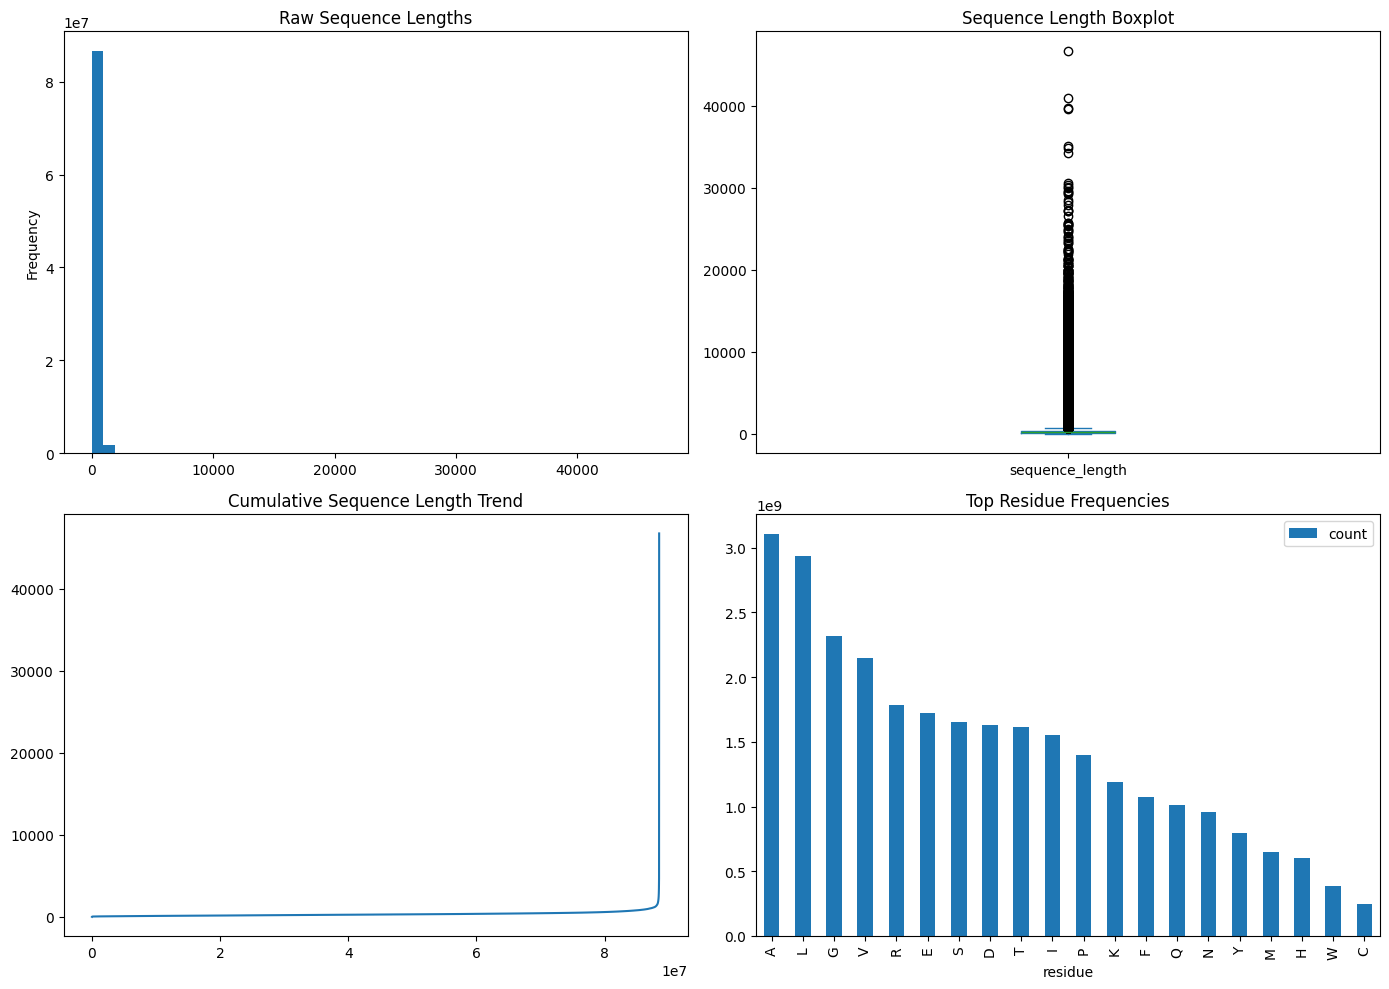

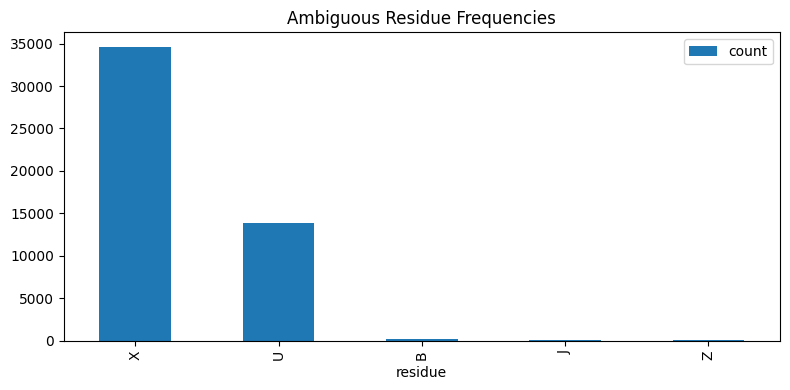

In [ ]:
sequence_length_series = pd.Series(sequence_length_values, name="sequence_length")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sequence_length_series.plot(kind="hist", bins=50, ax=axes[0, 0], title="Raw Sequence Lengths")
sequence_length_series.to_frame().plot(kind="box", ax=axes[0, 1], title="Sequence Length Boxplot")
sequence_length_series.sort_values().reset_index(drop=True).plot(ax=axes[1, 0], title="Cumulative Sequence Length Trend")
residue_frequency_df.head(20).plot(kind="bar", x="residue", y="count", ax=axes[1, 1], title="Top Residue Frequencies")
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(figure_output_path / "raw_sequence_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

if not ambiguous_residue_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ambiguous_residue_df.plot(kind="bar", x="residue", y="count", ax=ax, title="Ambiguous Residue Frequencies")
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(figure_output_path / "ambiguous_residue_frequencies.png", dpi=150, bbox_inches="tight")
    plt.show()

## Duplicate and Metadata Preview

Build raw and deduplicated views plus a metadata preview table for later curation.


In [ ]:
sequence_counter = Counter()
sequence_assembly_counter = Counter()

duplicate_scanner = protein_dataset.scanner(columns=["sequence", "assembly_id"], batch_size=PARSE_BATCH_SIZE, use_threads=True)
for batch in tqdm(duplicate_scanner.to_batches(), desc="Profiling duplicate structure", leave=False):
    sequences = batch.column("sequence").to_pylist()
    assemblies = batch.column("assembly_id").to_pylist()
    sequence_counter.update(sequences)
    sequence_assembly_counter.update(zip(assemblies, sequences))

raw_duplicate_groups = sum(1 for count in sequence_counter.values() if count > 1)
raw_duplicate_sequence_count = sum(count for count in sequence_counter.values() if count > 1)
within_assembly_duplicate_count = sum(count for count in sequence_assembly_counter.values() if count > 1)
across_assemblies_duplicate_count = max(raw_duplicate_sequence_count - within_assembly_duplicate_count, 0)

duplicate_summary_df = pd.DataFrame(
    [
        {
            "view_name": "raw_provenance",
            "duplicate_scope": "overall",
            "duplicate_group_count": int(raw_duplicate_groups),
            "duplicate_sequence_count": int(raw_duplicate_sequence_count),
            "duplicate_rate": float(raw_duplicate_sequence_count / total_record_count) if total_record_count else 0.0,
        },
        {
            "view_name": "raw_provenance",
            "duplicate_scope": "within_assembly",
            "duplicate_group_count": int(within_assembly_duplicate_count),
            "duplicate_sequence_count": int(within_assembly_duplicate_count),
            "duplicate_rate": float(within_assembly_duplicate_count / total_record_count) if total_record_count else 0.0,
        },
        {
            "view_name": "raw_provenance",
            "duplicate_scope": "across_assemblies",
            "duplicate_group_count": int(across_assemblies_duplicate_count),
            "duplicate_sequence_count": int(across_assemblies_duplicate_count),
            "duplicate_rate": float(across_assemblies_duplicate_count / total_record_count) if total_record_count else 0.0,
        },
        {
            "view_name": "deduplicated_candidate",
            "duplicate_scope": "overall",
            "duplicate_group_count": 0,
            "duplicate_sequence_count": 0,
            "duplicate_rate": 0.0,
        },
    ]
)

header_metadata_preview_df = protein_dataset.head(
    20,
    columns=[
        "assembly_id",
        "file_path",
        "sequence_id",
        "raw_header",
        "header_fields",
        "header_is_malformed",
    ],
).to_pandas()

if "header_fields" in header_metadata_preview_df.columns:
    header_expanded_df = pd.json_normalize(header_metadata_preview_df["header_fields"]).add_prefix("header_")
    header_metadata_preview_df = pd.concat([header_metadata_preview_df.drop(columns=["header_fields"]), header_expanded_df], axis=1)

display(duplicate_summary_df)
display(header_metadata_preview_df.head(20))

fig, ax = plt.subplots(figsize=(8, 4))
duplicate_summary_df[duplicate_summary_df["view_name"] == "raw_provenance"].plot(
    kind="bar",
    x="duplicate_scope",
    y="duplicate_rate",
    ax=ax,
    title="Duplicate Rate Summary",
)
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(figure_output_path / "duplicate_rate_summary.png", dpi=150, bbox_inches="tight")
plt.show()

Profiling duplicate structure: 0it [00:00, ?it/s]

### Duplicate and Metadata Preview: Output Notes

- Duplicate summary table reviewed for overall, within-assembly, and across-assemblies scopes.
- Header metadata preview table displayed and inspected for extracted fields.
- Duplicate-rate bar chart generated successfully.

Interpretation: Duplicate structure and header parse quality are now visible for data cleaning and deduplication policy decisions.


In [ ]:
artifacts = []

sequence_stats_parquet_path = artifact_output_path / "sequence_stats.parquet"
sequence_stats_preview_path = artifact_output_path / "sequence_stats_preview.csv"
if SAVE_ARTIFACTS:
    sequence_stats_scanner = protein_dataset.scanner(columns=sequence_stats_columns, batch_size=PARSE_BATCH_SIZE, use_threads=True)
    with pq.ParquetWriter(sequence_stats_parquet_path, sequence_stats_scanner.projected_schema, compression="zstd") as writer:
        for batch in sequence_stats_scanner.to_batches():
            writer.write_table(pa.Table.from_batches([batch]))

sequence_stats_preview_df.to_csv(sequence_stats_preview_path, index=False)
artifacts.extend(
    [
        {
            "artifact_name": sequence_stats_parquet_path.stem,
            "artifact_role": "table",
            "storage_format": "parquet",
            "path": str(sequence_stats_parquet_path),
            "analysis_scope": "configured",
            "source_view": None,
            "is_preview": False,
        },
        {
            "artifact_name": sequence_stats_preview_path.stem,
            "artifact_role": "table",
            "storage_format": "csv",
            "path": str(sequence_stats_preview_path),
            "analysis_scope": "configured",
            "source_view": None,
            "is_preview": True,
        },
    ]
)

if SAVE_ARTIFACTS:
    artifacts.extend(write_table_outputs(duplicate_summary_df, artifact_output_path / "duplicate_summary.parquet", artifact_output_path / "duplicate_summary_preview.csv", CSV_PREVIEW_ROW_LIMIT))
    artifacts.extend(
        write_table_outputs(header_metadata_preview_df, artifact_output_path / "header_metadata_preview.parquet", artifact_output_path / "header_metadata_preview.csv", CSV_PREVIEW_ROW_LIMIT)
    )

manifest = {
    "run_date": pd.Timestamp.utcnow().isoformat(),
    "data_root": DATA_ROOT,
    "max_length": MAX_LENGTH,
    "sample_mode": SAMPLE_MODE,
    "analysis_scope_override": ANALYSIS_SCOPE_OVERRIDE,
    "tokenization_strategies": TOKENIZATION_STRATEGIES,
    "ambiguous_residue_mode": AMBIGUOUS_RESIDUE_MODE,
    "rare_residue_policy": RARE_RESIDUE_POLICY,
    "records_storage": "pyarrow_parquet",
    "records_parquet_path": str(records_parquet_path),
    "artifacts": artifacts,
}

if SAVE_ARTIFACTS:
    write_manifest(manifest, results_output_path / "analysis_artifact_manifest.json")

display(pd.DataFrame(artifacts))
display(pd.DataFrame([manifest]).drop(columns=["artifacts"]))

NameError: name 'duplicate_summary_df' is not defined

### Artifact and Manifest: Output Notes

- Artifact inventory table displayed with storage format and paths.
- Manifest preview displayed with run configuration fields.
- Confirm artifact write status and any errors from the output block above.

Interpretation: Analysis outputs are tracked for reproducibility via tabular artifacts and the run manifest.
